# Regret-Focused Experiments (No Prediction Fairness)

This notebook compares method performance **without the prediction fairness objective**.
The problem reduces to: **predict benefit r, then solve α-fair allocation.**

**Methods compared:**
| Method | Type | Description |
|--------|------|-------------|
| SAA | Model-free | Constant predictor (mean training benefit) |
| WDRO | Robust ERM | Neural net with variance-regularized MSE |
| PTO | ETO/Predict-then-optimize | Neural net with standard MSE |
| DFL | Decision-focused learning | Neural net with decision regret gradient |
| PCGrad-nf | MOO (2 obj) | PCGrad on {decision regret, pred MSE} |
| MGDA-nf | MOO (2 obj) | MGDA on {decision regret, pred MSE} |

All methods run with **λ = 0** (no fairness penalty). The `-nf` MOO variants use the
`plg` base (2 objectives: decision + prediction) instead of `fplg` (3 objectives).

In [1]:
# Install dependencies (Colab)
!pip install -q torch numpy pandas scipy matplotlib cvxpy mosek
!pip install -q git+https://github.com/cvxpy/cvxtorch.git
!pip install -q --upgrade threadpoolctl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 97.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os, sys

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/colab_upload'
MOSEK_LIC_PATH = f'{DRIVE_ROOT}/data/mosek.lic'

if os.path.exists(MOSEK_LIC_PATH):
    os.environ['MOSEKLM_LICENSE_FILE'] = MOSEK_LIC_PATH
    print(f'MOSEK license set: {MOSEK_LIC_PATH}')
else:
    print(f'Warning: MOSEK license not found at {MOSEK_LIC_PATH}')

for p in [DRIVE_ROOT, os.path.join(DRIVE_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)


%cd {DRIVE_ROOT}
print(f'Working directory: {os.getcwd()}')

In [ ]:
# Verify imports — unified training pipeline
from fair_dfl.runner import run_experiment_unified
from configs import ALL_METHOD_CONFIGS, describe_method

print(f'{len(ALL_METHOD_CONFIGS)} methods available:')
for name, spec in ALL_METHOD_CONFIGS.items():
    print(f'  {name:15s} -> {describe_method(name, spec)}')

## 1. Experiment: No Prediction Fairness (λ = 0)

All methods use `--lambdas 0.0` so the fairness penalty is inactive.
For MOO methods, the `-nf` variants use the `plg` base which has only
2 objectives (decision regret + prediction MSE) instead of 3.

In [ ]:
METHODS = "SAA WDRO PTO DFL PCGrad-nf MGDA-nf"
RESULTS_DIR = "results/no_fairness"

In [5]:
# Quick test (500 samples, single alpha)
# !python run_methods.py \
#     --methods {METHODS} \
#     --alphas 0.5 \
#     --lambdas 0.0 \
#     --n-sample 20000 \
#     --results-dir {RESULTS_DIR} \
#     --overwrite

In [6]:
# Full run (all data, both alpha values)
# Uncomment when ready:

!python run_methods.py \
    --methods {METHODS} \
    --alphas 0.5 2.0 \
    --lambdas 0.0 \
    --results-dir {RESULTS_DIR} \
    --overwrite

Methods:    ['SAA', 'WDRO', 'PTO', 'DFL', 'PCGrad-nf', 'MGDA-nf']
Alphas:     [0.5, 2.0]
Lambdas:    [0.0]
Seeds:      [11, 22, 33]
Steps:      70
N-sample:   0 (0=all)
Device:     cuda
Results:    results_no_fairness
Overwrite:  True
Total runs: 12
Batch size (full training set): 19514

[1/12] alpha=0.5, method=SAA (backend=saa)
    Done in 6.2s | 3 stage rows | mean regret=77.6418, fairness=49.862783, pred_mse=248.6879, norm_regret=0.0752

[2/12] alpha=0.5, method=WDRO (backend=wdro)
    Done in 12.1s | 3 stage rows | mean regret=61.8688, fairness=32.943882, pred_mse=199.4889, norm_regret=0.0599

[3/12] alpha=0.5, method=PTO (backend=fpto)
    Done in 10.8s | 3 stage rows | mean regret=61.1865, fairness=56.275075, pred_mse=274.1369, norm_regret=0.0592

[4/12] alpha=0.5, method=DFL (backend=dfl)
    Done in 14.5s | 3 stage rows | mean regret=78.1202, fairness=106.934165, pred_mse=397.1574, norm_regret=0.0756

[5/12] alpha=0.5, method=PCGrad-nf (backend=plg)
    Done in 16.8s | 3 stage

## 2. Quick Results Comparison

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

stage_df = pd.read_csv(f'{RESULTS_DIR}/stage_results_full.csv')
print(f'Loaded {len(stage_df)} stage rows')
print(f'Methods: {sorted(stage_df["config_name"].unique())}')
print(f'Alphas:  {sorted(stage_df["alpha_fair"].unique())}')

Loaded 36 stage rows
Methods: ['DFL', 'MGDA-nf', 'PCGrad-nf', 'PTO', 'SAA', 'WDRO']
Alphas:  [np.float64(0.5), np.float64(2.0)]


In [8]:
# Summary table: mean +/- std across seeds
metrics = ['test_regret', 'test_pred_mse', 'test_fairness']
if 'test_regret_normalized' in stage_df.columns:
    metrics.insert(1, 'test_regret_normalized')

for alpha in sorted(stage_df['alpha_fair'].unique()):
    print(f'\n===== alpha_fair = {alpha} =====')
    sub = stage_df[stage_df['alpha_fair'] == alpha]
    summary = sub.groupby('config_name')[metrics].agg(['mean', 'std'])
    # Flatten multi-level columns
    summary.columns = [f'{m}_{s}' for m, s in summary.columns]
    # Sort by mean regret (ascending = better)
    sort_col = 'test_regret_normalized_mean' if 'test_regret_normalized_mean' in summary.columns else 'test_regret_mean'
    summary = summary.sort_values(sort_col)
    print(summary.round(4).to_string())


===== alpha_fair = 0.5 =====
             test_regret_mean  test_regret_std  test_regret_normalized_mean  test_regret_normalized_std  test_pred_mse_mean  test_pred_mse_std  test_fairness_mean  test_fairness_std
config_name                                                                                                                                                                          
PCGrad-nf             61.1671           1.8574                       0.0592                      0.0018            274.0625            25.1579             56.2378            10.5329
PTO                   61.1865           1.8747                       0.0592                      0.0018            274.1369            25.1674             56.2751            10.5343
WDRO                  61.8688           2.2784                       0.0599                      0.0022            199.4889             5.5132             32.9439             1.2078
SAA                   77.6418           0.0000              

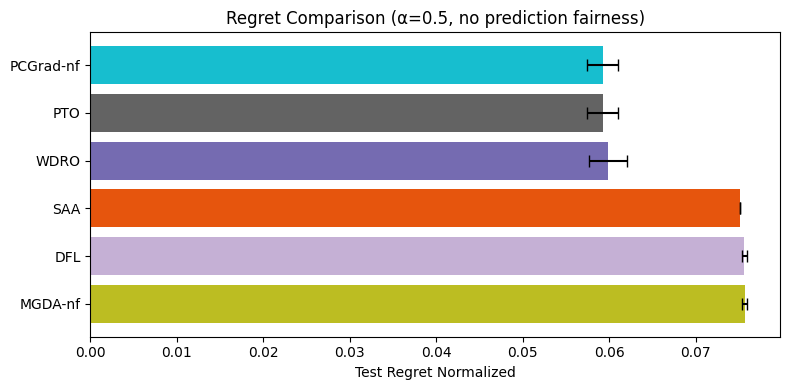

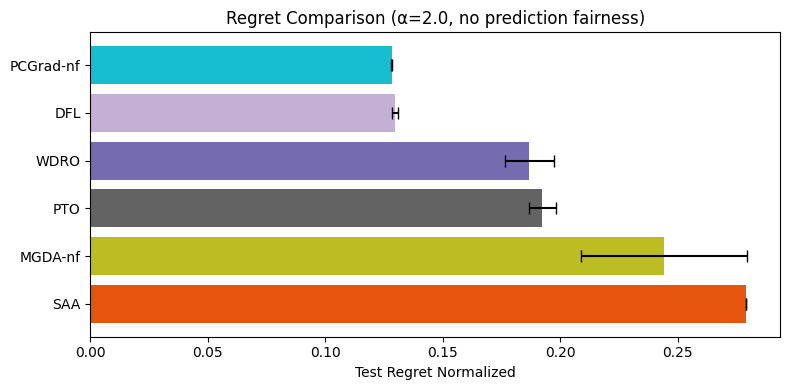

In [9]:
# Bar chart: normalized regret comparison
from configs import COLOR_MAP

for alpha in sorted(stage_df['alpha_fair'].unique()):
    sub = stage_df[stage_df['alpha_fair'] == alpha]
    regret_col = 'test_regret_normalized' if 'test_regret_normalized' in sub.columns else 'test_regret'
    stats = sub.groupby('config_name')[regret_col].agg(['mean', 'std']).sort_values('mean')

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = [COLOR_MAP.get(m, '#999999') for m in stats.index]
    ax.barh(stats.index, stats['mean'], xerr=stats['std'], color=colors, capsize=4)
    ax.set_xlabel(regret_col.replace('_', ' ').title())
    ax.set_title(f'Regret Comparison (\u03b1={alpha}, no prediction fairness)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

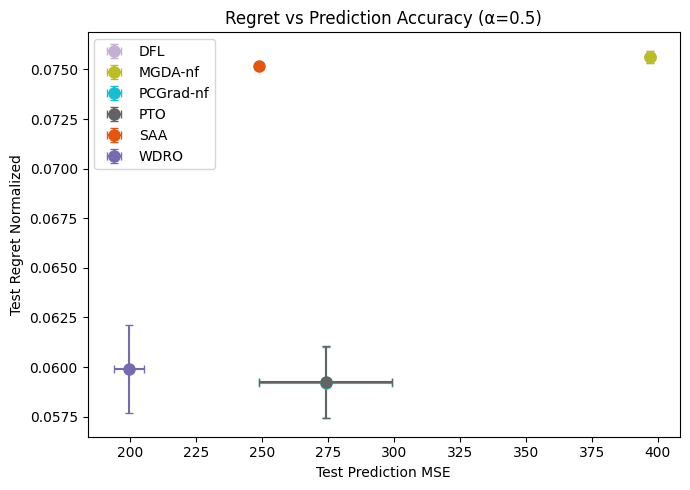

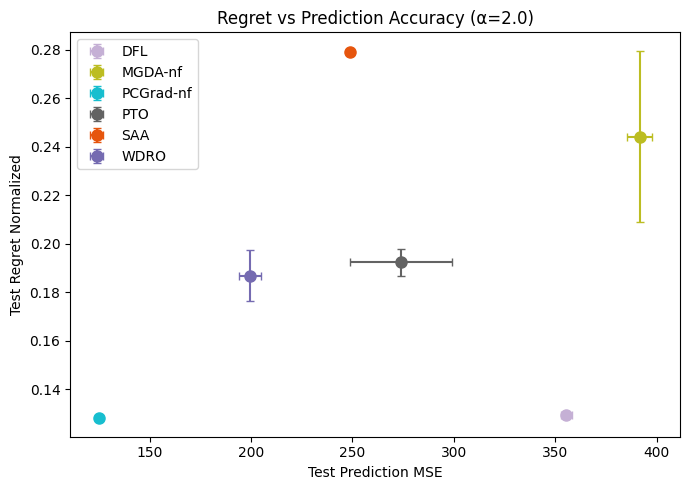

In [10]:
# Scatter: regret vs pred_mse (regret-accuracy tradeoff)
for alpha in sorted(stage_df['alpha_fair'].unique()):
    sub = stage_df[stage_df['alpha_fair'] == alpha]
    regret_col = 'test_regret_normalized' if 'test_regret_normalized' in sub.columns else 'test_regret'
    stats = sub.groupby('config_name').agg(
        regret_mean=(regret_col, 'mean'),
        regret_std=(regret_col, 'std'),
        mse_mean=('test_pred_mse', 'mean'),
        mse_std=('test_pred_mse', 'std'),
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    for method in stats.index:
        r = stats.loc[method]
        ax.errorbar(
            r['mse_mean'], r['regret_mean'],
            xerr=r['mse_std'], yerr=r['regret_std'],
            fmt='o', color=COLOR_MAP.get(method, '#999'),
            label=method, markersize=8, capsize=3,
        )
    ax.set_xlabel('Test Prediction MSE')
    ax.set_ylabel(regret_col.replace('_', ' ').title())
    ax.set_title(f'Regret vs Prediction Accuracy (\u03b1={alpha})')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. No Decision Fairness (α → 0)

To remove fairness from the **allocation decision** itself, change `alpha_fair`.
The α-fair utility is: $u_\alpha(r \cdot d) = \frac{(r \cdot d)^{1-\alpha}}{1-\alpha}$

- **α = 0**: Utilitarian/linear (maximize total benefit, no fairness)
- **α = 0.5**: Square-root utility (moderate fairness)
- **α = 1**: Log utility (proportional fairness)
- **α = 2**: Harmonic utility (strong fairness)

**Important caveat:** The current group-mode solver requires `α > 0`.
To run with α ≈ 0, either:
1. Use a small positive value (e.g., `--alphas 0.01`) in group mode
2. Switch to individual mode with `α = 0` (edit `make_task_cfg` in `configs.py` to set `decision_mode='individual'`)

**Option 1** is simpler and stays within the same experimental setup:

In [ ]:
# Near-utilitarian allocation (alpha ~= 0)
# Uncomment when ready:

!python run_methods.py \
    --methods {METHODS} \
    --alphas 0.1 \
    --lambdas 0.0 \
    --results-dir results/no_decision_fairness \
    --overwrite

To compare **with vs without** decision fairness, load both result sets:

In [ ]:
# Uncomment after running both experiments:

df_fair = pd.read_csv(f'{RESULTS_DIR}/stage_results_full.csv')
df_fair['setting'] = f'alpha={df_fair["alpha_fair"].values[0]}'

df_nofair = pd.read_csv('results/no_decision_fairness/stage_results_full.csv')
df_nofair['setting'] = f'alpha={df_nofair["alpha_fair"].values[0]}'

combined = pd.concat([df_fair, df_nofair], ignore_index=True)
regret_col = 'test_regret_normalized' if 'test_regret_normalized' in combined.columns else 'test_regret'
summary = combined.groupby(['setting', 'config_name'])[regret_col].agg(['mean', 'std']).round(4)
print(summary.to_string())